# Jour 2 — TP : mini-rapport exploratoire

## Consignes

**Travail en groupe, sur VOTRE dataset nettoyé au Jour 1** (celui de votre dépôt Git).

**Partie 1 — fin de matinée : réponses chiffrées**
Reprenez les questions métier formulées au Jour 1. Pour **au moins 3 d'entre elles**, produisez le tableau qui y répond (`groupby`, `agg`, `pivot_table`, nouvelles variables…) et rédigez une phrase de réponse chiffrée.

**Partie 2 — après-midi : le mini-rapport**
Transformez vos analyses en un mini-rapport de **5 à 8 visualisations commentées**, structuré comme un vrai livrable professionnel (modèle ci-dessous).

**Rendu** : ce notebook complété, qui s'exécute du début à la fin sans erreur (*Kernel → Restart & Run All*), commité et poussé sur Git **avant la fin de la journée**, avec un message explicite (ex. `J2 - mini-rapport exploratoire`).

## Ce qu'on attend de chaque analyse

**Question → tableau → graphique → commentaire en 3 temps** (constat chiffré, interprétation, suite).

Rappels du cours :
- un titre de graphique **énonce le message**, il ne décrit pas ;
- un taux global = **ratio des sommes**, pas moyenne des ratios ;
- `nunique` pour compter des clients, `count` pour des lignes ;
- une comparaison semaine / week-end se ramène au **nombre de jours**.

## Checklist avant de rendre

- [ ] Le notebook tourne du début à la fin après *Restart & Run All*
- [ ] Chaque graphique a un titre-message, des axes nommés et des unités
- [ ] Chaque graphique est suivi de son commentaire en 3 temps
- [ ] La synthèse en tête du rapport est rédigée (et cohérente avec les analyses)
- [ ] Le périmètre (filtres, période, règles métier) est indiqué
- [ ] Le code est commenté et les cellules inutiles supprimées
- [ ] Commit + push effectués

## Grille d'évaluation (sur 20)

| Critère | Points | Ce qu'on regarde |
|---|---|---|
| Pertinence métier | 4 | Les questions ont un vrai intérêt pour l'activité ; les réponses y répondent vraiment |
| Justesse des agrégations | 4 | Bons indicateurs, bons filtres, ratios bien calculés, pas de double comptage |
| Choix et lisibilité des graphiques | 5 | Type adapté à la question, titres-messages, axes et unités, tri, sobriété |
| Qualité des commentaires | 4 | Chiffrés, interprétés avec prudence, débouchant sur une suite concrète |
| Structure et reproductibilité | 3 | Notebook propre et ordonné, code commenté, exécution complète sans erreur, commit Git |
| *Bonus* | +1 | Un graphique Plotly interactif réellement utile |

---

# Food trucks : attentes des clients, moments de consommation et leviers de fidélisation

**Groupe :** Nosaiba Elkrekshi

**Contexte et périmètre :**
- **Source** : enquête par questionnaire auprès de consommateurs de food trucks (`foodtruck.csv`, nettoyé au Jour 1) — 407 répondants, 33 variables, aucune valeur manquante.
- **Période** : non renseignée dans le fichier (pas de date), aucune analyse temporelle n'est donc possible.
- **Unité d'analyse** : le répondant (une ligne = une personne, pas d'identifiant client, donc pas de double comptage).
- **Règles métier** : un client est dit *régulier* quand son code de fréquence est ≥ 2 ; l'analyse 5 se limite aux répondants de moins de 50 ans (au-delà, moins de 10 répondants par tranche) ; dans l'analyse 7, les canaux de moins de 30 répondants ne sont pas représentés.
- **Limites connues** : données déclaratives ; la dépense est déclarée par tranches (15, 20, 30, 40, 50 €), les moyennes sont donc approximatives.

## Synthèse

- **Le produit et l'hygiène sont non négociables** : le goût (4,77/5) et l'hygiène (4,65/5) sont les critères les mieux notés, loin devant la vente à emporter (2,73/5).
- **Le soir concentre l'activité** : le dîner représente 64 % des répondants avec une dépense moyenne de 22,2 €, contre 2 % pour le déjeuner.
- **Les réseaux sociaux font dépenser, le bouche-à-oreille fidélise** : les clients venus par les réseaux sociaux dépensent le plus (23,7 €), mais 20,9 % des clients venus par recommandation sont réguliers, contre 13,4 % via les réseaux sociaux.
- **La street food (72,5 %) et les desserts (37,8 %) dominent la demande**, et 65 % des répondants jugent les places assises importantes, contre 19 % pour la vente à emporter.
- **La dépense augmente avec le revenu (+16,5 % entre les classes 1 et 6)**, mais reste contenue (≈ 23 € au maximum) : le food truck reste perçu comme une restauration accessible.

## Préparation des données

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titleweight"] = "bold"

# Chargement du dataset nettoyé au Jour 1
df = pd.read_csv("foodtruck.csv")

print(f"Dataset prêt : {len(df)} répondants et {df.shape[1]} variables enregistrées.")

Dataset prêt : 407 répondants et 33 variables enregistrées.


In [2]:
# Création des variables utiles : libellés lisibles pour les graphiques

# Libellés des moments de consommation
df["moment_label"] = df["time"].map(
    {
        "dinner": "Dîner / Soirée",
        "happy_hour": "Afterwork",
        "afternoon": "Après-midi",
        "dawn": "Nuit",
        "lunch": "Déjeuner",
    }
)

# Libellés des canaux / motivations
df["canal_label"] = df["motivation"].map(
    {
        "social_network": "Réseaux sociaux",
        "friend": "Bouche-à-oreille",
        "y_chance": "Hasard / Passage",
        "we": "Sortie week-end",
        "ads": "Publicité",
    }
)

# Tranches d'âge explicites
df["tranche_age"] = df["age.group"].map(
    {
        1.0: "< 20 ans",
        2.0: "20-29 ans",
        3.0: "30-39 ans",
        4.0: "40-49 ans",
        5.0: "50-59 ans",
        6.0: "60-69 ans",
        7.0: "70+ ans",
        8.0: "Non précisé",
    }
)

df["statut_pro"] = df["has.work"].map(
    {1.0: "En activité", 0.0: "Sans emploi / Étudiant"}
)

print(f"Variables ajoutées : {df.shape[1] - 33} (total : {df.shape[1]} colonnes).")

Variables ajoutées : 4 (total : 37 colonnes).


## Analyses

### Analyse 1 — Les cuisines attendues

**Question métier :** Quel type de cuisine proposer pour toucher le plus de clients ?

**Indicateur(s) et périmètre :** part des répondants intéressés par chaque type de cuisine (nombre de mentions / 407 répondants ; plusieurs choix possibles, les pourcentages ne somment donc pas à 100 %).

In [3]:
# Analyse 1 : agrégation (groupby / agg / pivot_table…)

cuisines_dict = {
    "street_food__target": "Street food / Burgers",
    "sweets_desserts__target": "Desserts & Douceurs",
    "gourmet__target": "Cuisine Gourmet",
    "brazilian_food__target": "Cuisine Brésilienne",
    "snacks__target": "Snacks & En-cas",
    "italian_food__target": "Cuisine Italienne",
    "mexican_food__target": "Cuisine Mexicaine",
    "japanese_food__target": "Cuisine Japonaise",
    "healthy_food__target": "Alimentation Saine",
    "fitness_food__target": "Cuisine Fitness",
    "arabic_food__target": "Cuisine Arabe",
    "chinese_food__target": "Cuisine Chinoise",
}

pref_cuisines = (
    df[list(cuisines_dict.keys())]
    .sum()
    .rename(index=cuisines_dict)
    .to_frame(name="nb_mentions")
    .assign(pct_repondants=lambda x: (x["nb_mentions"] / len(df)) * 100)
    .sort_values(by="pct_repondants", ascending=True)
)

print(pref_cuisines.round(1))

                       nb_mentions  pct_repondants
Cuisine Chinoise                16             3.9
Cuisine Arabe                   25             6.1
Cuisine Fitness                 30             7.4
Alimentation Saine              33             8.1
Cuisine Japonaise               36             8.8
Cuisine Mexicaine               41            10.1
Cuisine Italienne               43            10.6
Snacks & En-cas                 67            16.5
Cuisine Brésilienne             72            17.7
Cuisine Gourmet                120            29.5
Desserts & Douceurs            154            37.8
Street food / Burgers          295            72.5


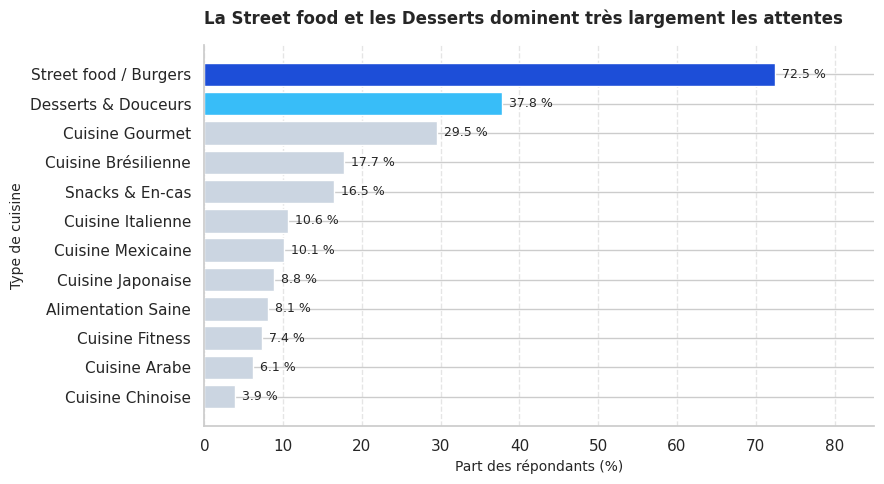

In [4]:
# Analyse 1 : graphique (titre-message, axes nommés avec unités)

fig, ax = plt.subplots(figsize=(9, 5))
couleurs = ["#cbd5e1"] * (len(pref_cuisines) - 2) + ["#38bdf8", "#1d4ed8"]

barres = ax.barh(
    pref_cuisines.index, pref_cuisines["pct_repondants"], color=couleurs
)

ax.set_title(
    "La Street food et les Desserts dominent très largement les attentes",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.set_xlabel("Part des répondants (%)", fontsize=10)
ax.set_ylabel("Type de cuisine", fontsize=10)
ax.set_xlim(0, 85)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in barres:
    largeur = bar.get_width()
    ax.annotate(
        f"{largeur:.1f} %",
        xy=(largeur, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

**Commentaire**

- Constat : La Street food arrive en tête incontestée avec 72,5 % de citations (295 répondants), suivie des Desserts & Douceurs (37,8 %) et de la Cuisine Gourmet (29,5 %). Les cuisines thématiques spécialisées (arabe, chinoise, fitness) restent sous le seuil des 8 %.

- Interprétation : Le concept de food truck reste étroitement associé dans l'esprit du public à des formats rapides, gourmands et réconfortants (burgers, tacos, douceurs sucrées).

- Suite : Structurer la carte autour d'une offre courte de burgers ou street food signature, systématiquement complétée par une formule menu incluant un dessert attractif.

### Analyse 2 — Moments de fréquentation et dépense moyenne

**Question métier :** Sur quels créneaux horaires l'activité doit-elle se positionner pour capter le plus de volume et de panier moyen ?   

**Indicateur(s) et périmètre :** Nombre de répondants, part (%) et dépense déclarée moyenne (€) par moment de la journée.  

In [5]:
# Analyse 2 : agrégation (groupby / agg / pivot_table…)

moments = (
    df.groupby("moment_label")
    .agg(
        nb_visiteurs=("time", "count"),
        part_visiteurs=("time", lambda x: len(x) / len(df) * 100),
        depense_moyenne=("expenses", "mean"),
    )
    .sort_values(by="nb_visiteurs", ascending=False)
)

print(moments.round(2))

                nb_visiteurs  part_visiteurs  depense_moyenne
moment_label                                                 
Dîner / Soirée           261           64.13            22.16
Afterwork                 51           12.53            22.65
Après-midi                47           11.55            17.77
Nuit                      39            9.58            19.87
Déjeuner                   9            2.21            21.67


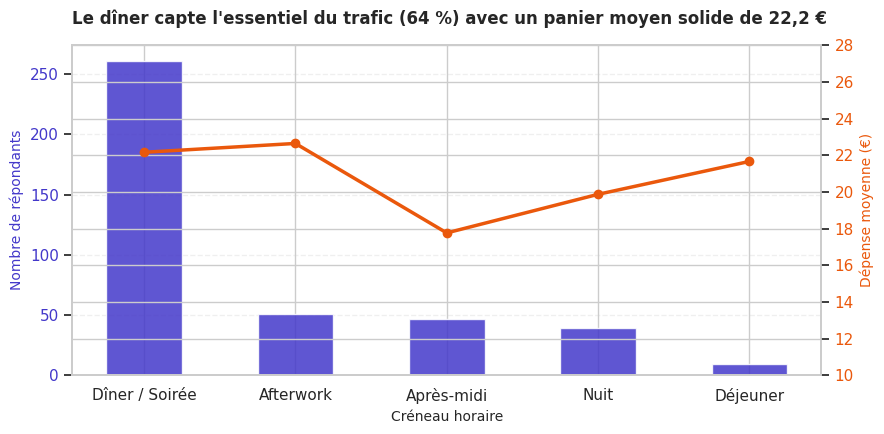

In [6]:
# Analyse 2 : graphique (titre-message, axes nommés avec unités)

fig, ax1 = plt.subplots(figsize=(9, 4.5))

ax1.bar(
    moments.index,
    moments["nb_visiteurs"],
    color="#4338ca",
    alpha=0.85,
    width=0.5,
    label="Nombre de visiteurs",
)
ax1.set_ylabel("Nombre de répondants", color="#4338ca", fontsize=10)
ax1.tick_params(axis="y", labelcolor="#4338ca")
ax1.set_xlabel("Créneau horaire", fontsize=10)

ax2 = ax1.twinx()
ax2.plot(
    moments.index,
    moments["depense_moyenne"],
    color="#ea580c",
    marker="o",
    linewidth=2.5,
    label="Dépense moyenne (€)",
)
ax2.set_ylabel("Dépense moyenne (€)", color="#ea580c", fontsize=10)
ax2.tick_params(axis="y", labelcolor="#ea580c")
ax2.set_ylim(10, 28)

plt.title(
    "Le dîner capte l'essentiel du trafic (64 %) avec un panier moyen solide de 22,2 €",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Commentaire**
- **Constat :** Le créneau Dîner / Soirée concentre 64,1 % des clients (261 répondants) avec une dépense moyenne de 22,2 €, tandis que l'afterwork affiche le panier le plus élevé (22,6 €). Le créneau déjeuner ne représente que 2,2 % des réponses.

- **Interprétation :** Le food truck n'est pas utilisé comme cantine du midi mais comme une expérience de détente en fin de journée et soirée.

- **Suite :** Concentrer les horaires d'ouverture et les effectifs en fin de journée et en soirée (les données ne précisent pas d'heures exactes), et privilégier des emplacements proches de zones de vie nocturne, bars ou places centrales.

### Analyse 3 — Canaux de découverte et dépense

**Question métier :** Comment les clients découvrent-ils le camion et quel canal apporte les plus gros paniers ?

**Indicateur(s) et périmètre :** Répartition des sources de découverte (%) et dépense moyenne (€)

In [7]:
# Analyse 3 : agrégation (groupby / agg / pivot_table…)

canaux = (
    df.groupby("canal_label")
    .agg(
        nb_clients=("motivation", "count"),
        part_clients=("motivation", lambda x: len(x) / len(df) * 100),
        depense_moyenne=("expenses", "mean"),
    )
    .sort_values(by="depense_moyenne", ascending=True)
)

print(canaux.round(2))

                  nb_clients  part_clients  depense_moyenne
canal_label                                                
Publicité                  4          0.98            17.50
Hasard / Passage          95         23.34            19.21
Bouche-à-oreille         139         34.15            20.76
Sortie week-end           20          4.91            21.50
Réseaux sociaux          149         36.61            23.72


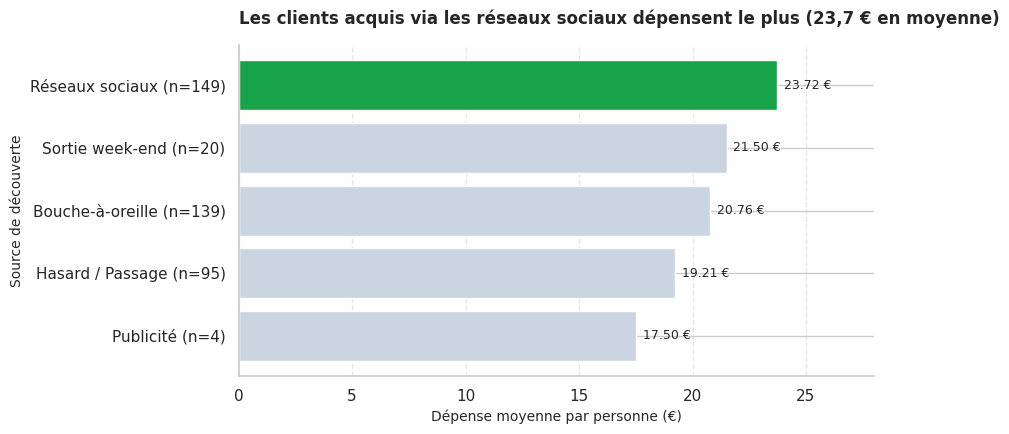

In [8]:
# Analyse 3 : graphique (titre-message, axes nommés avec unités)

fig, ax = plt.subplots(figsize=(9, 4.5))
couleurs = ["#cbd5e1"] * (len(canaux) - 1) + ["#16a34a"]

# Effectifs affichés dans les libellés pour signaler les petits groupes (ex. Publicité, n = 4)
libelles = [f"{c} (n={n})" for c, n in zip(canaux.index, canaux["nb_clients"])]
barres = ax.barh(libelles, canaux["depense_moyenne"], color=couleurs)

ax.set_title(
    "Les clients acquis via les réseaux sociaux dépensent le plus (23,7 € en moyenne)",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.set_xlabel("Dépense moyenne par personne (€)", fontsize=10)
ax.set_ylabel("Source de découverte", fontsize=10)
ax.set_xlim(0, 28)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in barres:
    largeur = bar.get_width()
    ax.annotate(
        f"{largeur:.2f} €",
        xy=(largeur, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

**Commentaire**
- **Constat :** Les clients venus via les réseaux sociaux affichent la dépense moyenne la plus élevée (23,72 €), devançant les sorties week-end (21,50 €), le bouche-à-oreille (20,76 €) et les passages par hasard (19,21 €). De plus, réseaux sociaux et bouche-à-oreille regroupent ensemble 70,8 % du flux total.

- **Interprétation :** Le client attiré par les réseaux sociaux vient souvent pour un plat repéré en ligne et semble plus enclin à commander un menu complet. Prudence : l'écart avec le bouche-à-oreille (≈ 3 €) reste modeste et n'a pas été testé statistiquement ; le canal Publicité (n = 4) n'est pas interprétable.

- **Suite :** Allouer un budget marketing ciblé sur le contenu photo/vidéo (Instagram, TikTok) et encourager le partage de stories (offrir un topping ou un café contre tag du compte).

### Analyse 4 — Hiérarchie des critères d'exigence des clients





**Question métier :** Quels facteurs conditionnent directement la satisfaction et le choix du consommateur ?

**Indicateur(s) et périmètre :** Note moyenne d'importance (échelle Likert de 1 à 5) sur 11 critères opérationnels

In [9]:
# Analyse 4 : agrégation (groupby / agg / pivot_table…)

criteres = {
    "taste": "Goût & Saveur",
    "hygiene": "Hygiène & Propreté",
    "attendance": "Qualité de l'accueil",
    "ingredients": "Qualité des ingrédients",
    "presentation": "Présentation des plats",
    "place.to.sit": "Espace pour s'asseoir",
    "menu": "Clarté du menu",
    "variation": "Diversité de l'offre",
    "takeaway": "Vente à emporter",
    "stop.strucks": "Emplacement fixe/régulier",
    "schedule": "Régularité des horaires",
}

notes_criteres = (
    df[list(criteres.keys())]
    .mean()
    .rename(index=criteres)
    .sort_values(ascending=True)
)

print(notes_criteres.round(2))

Régularité des horaires      2.66
Emplacement fixe/régulier    2.69
Vente à emporter             2.73
Diversité de l'offre         3.42
Clarté du menu               3.77
Espace pour s'asseoir        3.79
Présentation des plats       4.27
Qualité des ingrédients      4.48
Qualité de l'accueil         4.54
Hygiène & Propreté           4.65
Goût & Saveur                4.77
dtype: float64


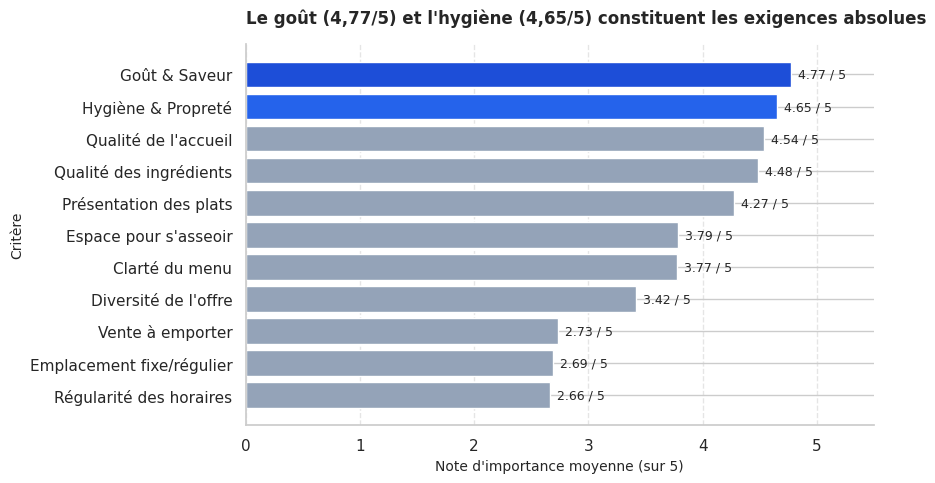

In [10]:
# Analyse 4 : graphique (titre-message, axes nommés avec unités)

fig, ax = plt.subplots(figsize=(9, 5))
couleurs = ["#94a3b8"] * (len(notes_criteres) - 2) + ["#2563eb", "#1d4ed8"]

barres = ax.barh(notes_criteres.index, notes_criteres.values, color=couleurs)

ax.set_title(
    "Le goût (4,77/5) et l'hygiène (4,65/5) constituent les exigences absolues",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.set_xlabel("Note d'importance moyenne (sur 5)", fontsize=10)
ax.set_ylabel("Critère", fontsize=10)
ax.set_xlim(0, 5.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in barres:
    largeur = bar.get_width()
    ax.annotate(
        f"{largeur:.2f} / 5",
        xy=(largeur, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

**Commentaire**
- **Constat :** Le trio de tête est formé par le Goût (4,77/5), l'Hygiène (4,65/5) et le Service (4,54/5). À l'opposé, la vente à emporter (2,73/5) et la régularité des horaires (2,66/5) obtiennent les scores les plus faibles. L'espace pour s'asseoir recueille une note notable de 3,79/5.

- **Interprétation :** La peur du manque d'hygiène reste le frein numéro 1 pour un food truck. Par ailleurs, les clients recherchent un lieu où consommer sur place dans une ambiance chaleureuse plutôt qu'un simple drive-in à emporter.

- **Suite :** Cuisiner devant le client dans un espace visiblement irréprochable et prévoir quelques mange-debout et tabourets pliants devant le camion pour faciliter la consommation immédiate.

### Analyse 5 — Dépense moyenne selon la tranche d'âge et l'activité professionnelle

**Question métier :** Comment varie le panier moyen selon l'âge et le statut professionnel du client ?

**Indicateur(s) et périmètre :** Dépense moyenne (€) et effectif par tranche d'âge et statut professionnel (has.work)

In [11]:
# Analyse 5 : agrégation (groupby / agg / pivot_table…)
age_work = (
    df[df["tranche_age"].isin(["< 20 ans", "20-29 ans", "30-39 ans", "40-49 ans"])]
    .groupby(["tranche_age", "statut_pro"])
    .agg(depense_moyenne=("expenses", "mean"), effectif=("expenses", "count"))
    .reset_index()
)

print(age_work.round(2))

  tranche_age              statut_pro  depense_moyenne  effectif
0   20-29 ans             En activité            21.88        88
1   20-29 ans  Sans emploi / Étudiant            21.13        97
2   30-39 ans             En activité            22.50        50
3   30-39 ans  Sans emploi / Étudiant            20.00        11
4   40-49 ans             En activité            23.52        27
5   40-49 ans  Sans emploi / Étudiant            22.50         6
6    < 20 ans             En activité            21.14        22
7    < 20 ans  Sans emploi / Étudiant            19.94        79


In [12]:
# Analyse 5 : graphique (titre-message, axes nommés avec unités)

fig = px.bar(
    age_work,
    x="tranche_age",
    y="depense_moyenne",
    color="statut_pro",
    barmode="group",
    title="Les actifs de 40-49 ans et 30-39 ans génèrent les paniers les plus élevés",
    labels={
        "tranche_age": "Tranche d'âge",
        "depense_moyenne": "Dépense moyenne déclarée (€)",
        "statut_pro": "Statut professionnel",
        "effectif": "Nombre de répondants",
    },
    hover_data={"depense_moyenne": ":.2f", "effectif": True},
    color_discrete_sequence=["#1d4ed8", "#93c5fd"],
    category_orders={"tranche_age": ["< 20 ans", "20-29 ans", "30-39 ans", "40-49 ans"]},
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(title="Dépense déclarée (€)", range=[0, 30]),
    legend_title_text="Situation professionnelle",
)
fig.show()

**Commentaire**
- **Constat :** Chez les personnes en activité, le panier progresse régulièrement avec l'âge : de 21,1 € (< 20 ans) à 21,9 € (20-29 ans), puis 22,5 € (30-39 ans) et 23,5 € (40-49 ans). Les étudiants et personnes sans activité maintiennent un panier inférieur mais stable (~20 à 21 €).

- **Interprétation :** Le pouvoir d'achat supérieur des trentenaires et quadragénaires actifs leur permet probablement de consommer des formules plus complètes. Prudence : certains sous-groupes sont très petits (11 sans-emploi de 30-39 ans, 6 de 40-49 ans), leurs moyennes sont peu fiables.

- **Suite :** Créer une offre « Duo / Afterwork Pro » valorisée à 24-25 € ciblant spécifiquement les actifs en sortie de bureau.

### Analyse 6 — Évolution de la dépense déclarée selon le niveau de revenu

**Question métier :** Dans quelle mesure le niveau de revenu conditionne-t-il le budget alloué au food truck ?

**Indicateur(s) et périmètre :** Dépense moyenne déclarée (€) et effectif par niveau de revenu (average.income, échelle ordinale 1 à 6).

In [13]:
revenu_depense = (
    df.groupby("average.income")
    .agg(
        effectif=("expenses", "count"),
        depense_moyenne=("expenses", "mean"),
        depense_mediane=("expenses", "median"),
    )
    .reset_index()
)

print(revenu_depense.round(2))

   average.income  effectif  depense_moyenne  depense_mediane
0             1.0        99            19.95             20.0
1             2.0        72            20.56             20.0
2             3.0        89            21.97             20.0
3             4.0        75            22.33             20.0
4             5.0        38            22.89             20.0
5             6.0        34            23.24             20.0


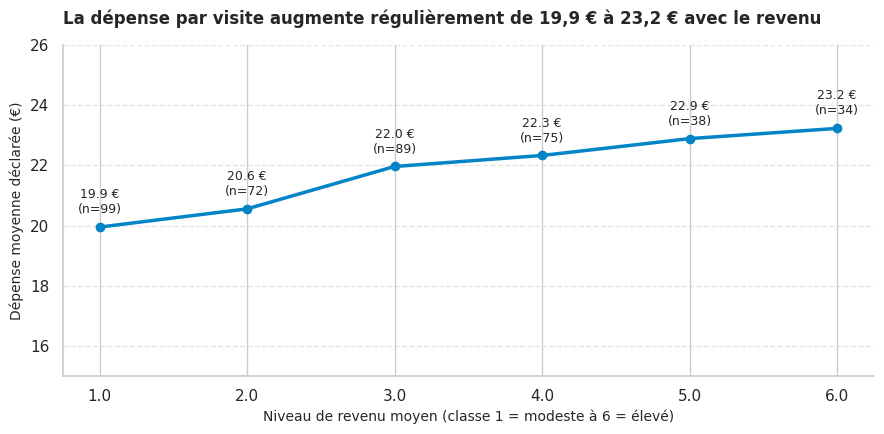

In [14]:
# Graphique

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(
    revenu_depense["average.income"].astype(str),
    revenu_depense["depense_moyenne"],
    marker="o",
    color="#0284c7",
    linewidth=2.5,
    label="Dépense moyenne (€)",
)

ax.set_title(
    "La dépense par visite augmente régulièrement de 19,9 € à 23,2 € avec le revenu",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.set_xlabel("Niveau de revenu moyen (classe 1 = modeste à 6 = élevé)", fontsize=10)
ax.set_ylabel("Dépense moyenne déclarée (€)", fontsize=10)
ax.set_ylim(15, 26)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for _, row in revenu_depense.iterrows():
    ax.annotate(
        f"{row['depense_moyenne']:.1f} €\n(n={int(row['effectif'])})",
        xy=(row["average.income"] - 1, row["depense_moyenne"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

**Commentaire**   

- **Constat :** La dépense moyenne progresse de manière linéaire avec le niveau de revenu, passant de 19,95 € pour la tranche 1 à 23,24 € pour la tranche 6 (+16,5 %). La médiane, elle, reste à 20 € dans toutes les classes : l'écart vient surtout d'une part plus importante de gros paniers chez les revenus élevés.

- **Interprétation :** Le produit conserve une faible sensibilité au prix : même les foyers aux revenus plus élevés plafonnent à environ 23 €, ce qui confirme que le format food truck est perçu comme une formule de restauration accessible et non un substitut de table gastronomique.

- **Suite :** Proposer un produit signature ou une option boisson artisanale premium (+2 € à 3 €) pour capter le consentement à payer supérieur des clients des classes 5 et 6.

### Analyse 7 — Fidélité et fréquence d'achat selon le canal de venue

**Question métier :** Quel canal attire les consommateurs les plus fidèles et réguliers ?

**Indicateur(s) et périmètre :** Score moyen de fréquence de visite (frequency) et proportion de clients réguliers (fréquence $\ge$ 2) par motivation. 

In [15]:
# Agregation

canal_fidelite = (
    df.groupby("canal_label")
    .agg(
        effectif=("frequency", "count"),
        score_freq_moyen=("frequency", "mean"),
        part_frequents=("frequency", lambda x: (x >= 2).mean() * 100),
    )
    .sort_values(by="part_frequents", ascending=True)
)

print(canal_fidelite.round(2))

                  effectif  score_freq_moyen  part_frequents
canal_label                                                 
Sortie week-end         20              0.45           10.00
Réseaux sociaux        149              0.79           13.42
Hasard / Passage        95              0.67           16.84
Bouche-à-oreille       139              0.84           20.86
Publicité                4              0.50           25.00


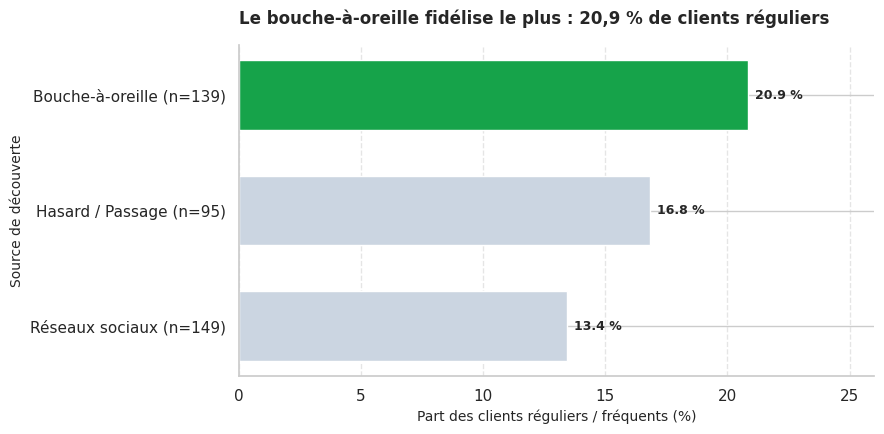

In [16]:
# Graphique

# On ne représente que les canaux d'au moins 30 répondants :
# "Publicité" (n = 4, soit 1 régulier sur 4 = 25 %) et "Sortie week-end" (n = 20) ne sont pas interprétables
canal_graph = canal_fidelite[canal_fidelite["effectif"] >= 30]

fig, ax = plt.subplots(figsize=(9, 4.5))
couleurs = ["#16a34a" if c == "Bouche-à-oreille" else "#cbd5e1" for c in canal_graph.index]
libelles = [f"{c} (n={n})" for c, n in zip(canal_graph.index, canal_graph["effectif"])]

barres = ax.barh(
    libelles,
    canal_graph["part_frequents"],
    color=couleurs,
    height=0.6,
)

ax.set_title(
    "Le bouche-à-oreille fidélise le plus : 20,9 % de clients réguliers",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.set_xlabel("Part des clients réguliers / fréquents (%)", fontsize=10)
ax.set_ylabel("Source de découverte", fontsize=10)
ax.set_xlim(0, 26)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in barres:
    val = bar.get_width()
    ax.annotate(
        f"{val:.1f} %",
        xy=(val, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="semibold",
    )

plt.tight_layout()
plt.show()


**Commentaire**   

- **Constat :** Le bouche-à-oreille génère le taux de clients réguliers le plus solide avec 20,9 % (score moyen de 0,84), devançant le passage impromptu (16,8 %) et les réseaux sociaux (13,4 %). Les canaux Publicité (n = 4) et Sortie week-end (n = 20) sont exclus du graphique : un taux de 25 % sur 4 personnes correspond à un seul client régulier.

- **Interprétation :** Si les réseaux sociaux amènent un volume important et de gros paniers d'achat lors de la première venue (cf. Analyse 3), la fidélisation dans la durée s'appuie avant tout sur la réputation locale et la recommandation par les pairs.

- **Suite :** Mettre en place un programme de parrainage physique (ex. une carte de fidélité tamponnée avec réduction offerte pour un ami amené) pour transformer l'afflux initial des réseaux sociaux en visites répétées.

### Analyse 8 — Comparaison des attentes de service : Consommation sur place vs À emporter

**Question métier :** Faut-il investir dans du mobilier de dégustation ou privilégier un modèle 100 % vente à emporter ?

**Indicateur(s) et périmètre :** Distribution des notes d'importance attribuées (de 1 = pas important à 5 = essentiel) pour place.to.sit et takeaway.

In [17]:
# Agrégation

notes_distribution = pd.DataFrame(
    {
        "Sur place (place pour s'asseoir)": (
            df["place.to.sit"].value_counts(normalize=True).sort_index() * 100
        ),
        "À emporter (takeaway)": (
            df["takeaway"].value_counts(normalize=True).sort_index() * 100
        ),
    }
).fillna(0)

print(notes_distribution.round(1))

     Sur place (place pour s'asseoir)  À emporter (takeaway)
1.0                               2.9                   11.1
2.0                              15.5                   27.8
3.0                              16.5                   42.3
4.0                              30.2                   14.7
5.0                              34.9                    4.2


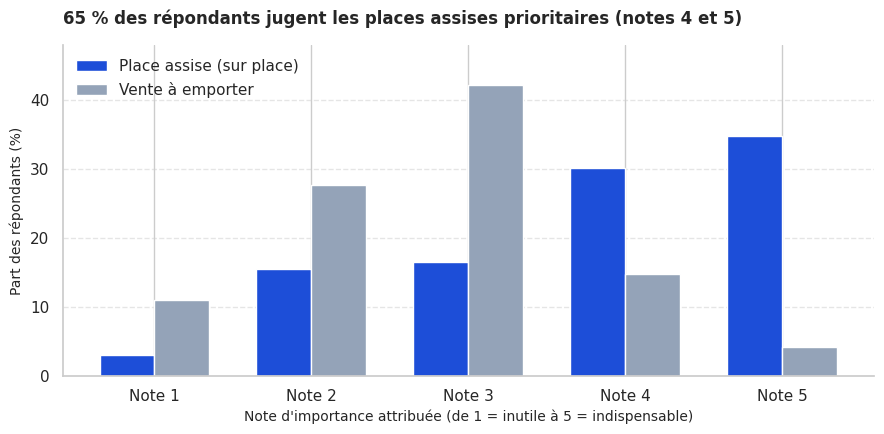

In [18]:
# Graphique

fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(1, 6)
largeur = 0.35

ax.bar(
    x - largeur / 2,
    notes_distribution["Sur place (place pour s'asseoir)"],
    width=largeur,
    color="#1d4ed8",
    label="Place assise (sur place)",
)
ax.bar(
    x + largeur / 2,
    notes_distribution["À emporter (takeaway)"],
    width=largeur,
    color="#94a3b8",
    label="Vente à emporter",
)

ax.set_title(
    "65 % des répondants jugent les places assises prioritaires (notes 4 et 5)",
    fontsize=12,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.set_xlabel("Note d'importance attribuée (de 1 = inutile à 5 = indispensable)", fontsize=10)
ax.set_ylabel("Part des répondants (%)", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f"Note {i}" for i in range(1, 6)])
ax.set_ylim(0, 48)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()

**Commentaire**

**Constat :** 65,1 % des répondants attribuent une note de 4 ou 5 à l'aménagement d'un espace assise (place.to.sit), contre seulement 18,9 % pour la vente à emporter (takeaway), qui cumule une majorité d'avis neutres ou faibles (note 3 à 42,3 %, note 2 à 27,8 %).

**Interprétation :** Le public ne conçoit pas le food truck comme un simple point de retrait rapide pour rentrer chez soi, mais comme une expérience de convivialité et de consommation immédiate sur le lieu de vente.

**Suite :** Sélectionner des emplacements autorisant la pose de quelques tables ou mange-debout et négocier l'occupation de terrasse éphémère auprès des municipalités ou organisateurs d'événements.

## Limites et pistes pour le Jour 3

**Limites**

- Biais déclaratif et absence de données transactionnelles : Les dépenses et la fréquence reposent uniquement sur des estimations déclarées par les 407 sondés lors d'un questionnaire, sans confrontation avec des tickets de caisse réels ni mesure de saisonnalité calendaire.

- Biais de représentativité démographique : Plus de 70 % de l'échantillon a moins de 30 ans (24,8 % de moins de 20 ans et 45,5 % de 20-29 ans), ce qui sous-représente les familles et les seniors (les tranches au-delà de 50 ans comptent moins de 10 répondants chacune).

- Faiblesse de certains sous-échantillons : Le créneau du déjeuner (lunch, 9 répondants) et le canal publicitaire (ads, 4 répondants) affichent des effectifs trop réduits pour en tirer des moyennes statistiquement robustes.

- Absence d'informations géographiques et financières réelles : Le jeu de données ne précise pas l'emplacement géographique des camions (centre-ville, zones de bureaux, festivals) ni la rentabilité unitaire réelle (coût de revient matière, marge brute).


**Pistes pour le Jour 3**

- Segmentation et typologie de clientèle (Clustering) : Appliquer un algorithme non supervisé (K-Means ou classification hiérarchique) sur les critères de satisfaction et les habitudes de fréquentation afin de dresser des personas opérationnels (ex. le jeune actif afterwork, l'étudiant noctambule, le client de passage).


- Modélisation prédictive de la dépense : Entraîner un modèle de régression pour quantifier l'impact marginal du revenu (average.income), du moment de visite (time) et du niveau d'études (scholarity) sur le consentement à payer.


- Analyse de corrélation croisée sur l'offre : Explorer les associations entre les types de cuisine plébiscités (market basket analysis sur les variables __target) pour construire des formules menus complémentaires optimisées (ex. combo burger gourmet + dessert artisanal).


- Étude de l'élasticité et priorisation d'investissement : Croiser l'importance accordée à la place assise (place.to.sit) avec la fréquence déclarée pour évaluer le gain de fidélisation généré par l'aménagement d'une terrasse éphémère.